In [2]:
# Text preprocessing - Chargement des URLs des trois livres (Project Gutenberg) :
URLS = {
    "alice": "https://www.gutenberg.org/files/11/11-0.txt",
    "looking_glass": "https://www.gutenberg.org/files/12/12-0.txt",
    "tangled_tale": "https://www.gutenberg.org/files/29042/29042-0.txt",
}

In [7]:
#1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.
    # Création de la fonction 'load texts'

import re, requests
from typing import List, Dict


def load_texts(url_dict: Dict[str, str]) -> Dict[str, str]:
    """
    Télécharge chaque texte, enlève tout ce qui n’est pas mot (a-z, ’),
    et renvoie un dictionnaire {titre: texte_propre}.
    """
    corpus = {}
    pattern = re.compile(r"[^A-Za-zÀ-ÖØ-öø-ÿ']+")  # garde les lettres & l'apostrophe

    for title, url in url_dict.items():
        print(f"⇣ Téléchargement : {title}")
        raw = requests.get(url).text

        # Couper le header/footer Gutenberg (entre START et END)
        start = raw.find("START")      # index premier ‘START’
        end   = raw.rfind("END")       # dernier ‘END’
        sliced = raw[start:end]

        # Nettoyer
        cleaned = re.sub(pattern, " ", sliced).lower()
        corpus[title] = cleaned

    return corpus

corpus = load_texts(URLS)

⇣ Téléchargement : alice
⇣ Téléchargement : looking_glass
⇣ Téléchargement : tangled_tale


In [23]:
#2. Print the first 200 characteres of each text.
    # Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

for title, text in corpus.items():
    print(f"\n📖 {title} – 200 premiers caractères :\n{text[:200]}…")

    # hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:
        # ‘ START’
        # ‘ END’

    def extract_book_text(text):
      start_keywords = ['*** START OF', 'START OF THIS PROJECT GUTENBERG EBOOK']
      end_keywords = ['*** END OF', 'END OF THE PROJECT GUTENBERG EBOOK']



📖 alice – 200 premiers caractères :
start of the project gutenberg ebook illustration alice s adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbit hole chapter ii the pool of tears …

📖 looking_glass – 200 premiers caractères :
start of the project gutenberg ebook illustration through the looking glass and what alice found there by lewis carroll the millennium fulcrum edition dramatis personæ as arranged before commencement …

📖 tangled_tale – 200 premiers caractères :
…


In [34]:
#3. Tokenize the text and print the first 150 tokens of each book

import nltk
nltk.download('punkt')  # Télécharger les données nécessaires
nltk.download('punkt_tab') # Download the missing resource

def tokenize(text):
    return nltk.word_tokenize(text)

tokens_per_book = {title: tokenize(txt) for title, txt in corpus.items()}

for title, toks in tokens_per_book.items():
    print(f"{title} → {len(toks)} tokens")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


alice → 27434 tokens
looking_glass → 31102 tokens
tangled_tale → 0 tokens


In [35]:
#4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

from nltk.corpus import stopwords
nltk.download("stopwords")
stops = set(stopwords.words("english"))

def remove_stops(tokens):
    return [tok for tok in tokens if tok not in stops]

tokens_nostop = {t: remove_stops(toklist) for t, toklist in tokens_per_book.items()}

# Prouver que ça a marché
print("'myself' in alice ?", tokens_per_book["alice"].count("myself"))
print("'myself' in alice (nostop) ?", tokens_nostop["alice"].count("myself"))

'myself' in alice ? 7
'myself' in alice (nostop) ? 0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [36]:
#5. Using PorterStemmer(), print the first 50 stemmed tokens

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stem(tokens):
    return [stemmer.stem(t) for t in tokens]

stems = {t: stem(toklist) for t, toklist in tokens_nostop.items()}
print(stems["alice"][:50])

['start', 'project', 'gutenberg', 'ebook', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter', 'viii', 'queen', 'croquet']


In [39]:
#6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))          # reconstruire la phrase
    return [tok.lemma_ for tok in doc]

lemmas = {t: lemmatize(toklist) for t, toklist in tokens_nostop.items()}
print(lemmas["alice"][:50])


['start', 'project', 'gutenberg', 'ebook', 'illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 'croquet']


In [40]:
# 7.Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

#Stemming (Porter) : règles simples basées sur des suffixes (running → run, mais aussi run → run)
#Lemmatization (spaCy) : analyse morphologique + dico (better → good)

#Le stemming peut produire des racines qui ne sont pas des vrais mots. La lemmatisation fournit le mot‐dictionnaire; elle est plus lente et nécessite un modèle.


In [47]:
# 8. Using NLTK, identify POS tags od each text.
      # POS-tagging avec NLTK (mécanisme de base) - NLTK a besoin de tokens déjà créés (étape 2) + de son modèle percetron.
      # Télécharger les ressources nécessaires

import nltk
nltk.download("averaged_perceptron_tagger")       # Fonction pour taguer un livre

for title, txt in corpus.items():
    doc = nlp(txt[:5000])          # juste un extrait pour la démo
    print(f"\n🖇️  POS tags – {title}")
    for tok in doc[:40]:
        print(f"{tok.text:<12} {tok.pos_}")

    print(f"\n🏷️  Entities – {title}")
    for ent in doc.ents[:40]:
        print(f"{ent.text:<30} {ent.label_}")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!



🖇️  POS tags – alice
start        NOUN
of           ADP
the          DET
project      NOUN
gutenberg    PROPN
ebook        VERB
illustration PROPN
alice        PROPN
s            PART
adventures   NOUN
in           ADP
wonderland   NOUN
by           ADP
lewis        PROPN
carroll      PROPN
the          DET
millennium   NOUN
fulcrum      PROPN
edition      PROPN
contents     NOUN
chapter      NOUN
i            PRON
down         ADP
the          DET
rabbit       NOUN
hole         NOUN
chapter      PROPN
ii           PROPN
the          DET
pool         NOUN
of           ADP
tears        PROPN
chapter      PROPN
iii          PROPN
a            DET
caucus       NOUN
race         NOUN
and          CCONJ
a            DET
long         ADJ

🏷️  Entities – alice
millennium                     DATE
chapter iii                    LAW
caterpillar                    ORG
chapter x                      LAW
chapter xi                     PERSON
chapter xii                    LAW
alice s              

In [85]:
# 9. Using NLTK identify all the entities of each text
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
nltk.download('punkt')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

# Exemple : analyser toutes les entités nommées dans chaque texte du corpus
def extract_named_entities(text):
  tokens = word_tokenize(text)
  tagged = pos_tag(tokens)
  tree = ne_chunk(tagged)

  named_entities = []
  for subtree in tree:
    if hasattr(subtree, 'label'):
      entity = " ".join([leaf[0] for leaf in subtree.leaves()])
      label = subtree.label()
      named_entities.append((entity, label))
  return named_entities

# Appliquer à chaque texte du corpus
entities_per_book = {title: extract_named_entities(txt) for title, txt in corpus.items()}

# Afficher un exemple d'entités extraites
for title, entities in entities_per_book.items():
    print(f"\n📘 {title} — {len(entities)} entités nommées trouvées")
    print(entities[:10])  # Afficher les 10 premières entités


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.



📘 alice — 0 entités nommées trouvées
[]

📘 looking_glass — 0 entités nommées trouvées
[]

📘 tangled_tale — 0 entités nommées trouvées
[]


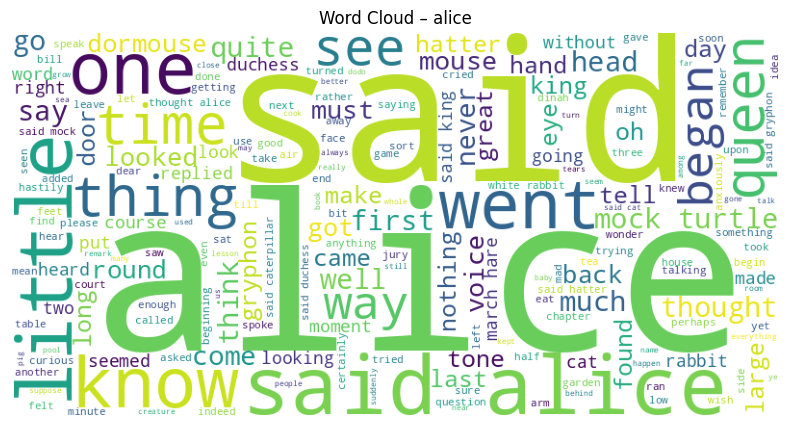

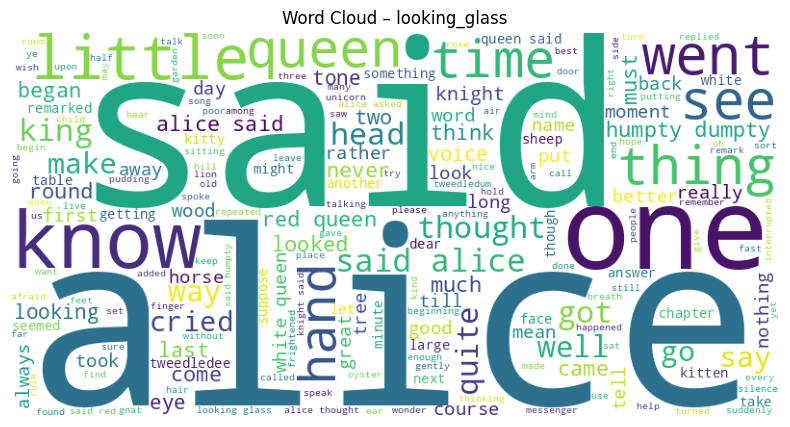

ValueError: We need at least 1 word to plot a word cloud, got 0.

In [86]:
# II - Analysing the text
  #1. Using wordcloud and matplotlib, display a word cloud of each book.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(tokens, title):
    txt = " ".join(tokens)
    wc = WordCloud(width=800, height=400, background_color="white").generate(txt)
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

for title, toks in tokens_nostop.items():
    show_wordcloud(toks, f"Word Cloud – {title}")



7. Word Clouds
7.1 Générer
python
Copier
Modifier
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(tokens, title):
    txt = " ".join(tokens)
    wc = WordCloud(width=800, height=400, background_color="white").generate(txt)
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

for title, toks in tokens_nostop.items():
    show_wordcloud(toks, f"Word Cloud – {title}")
7.2 Lecture
Cherche : noms propres (Alice, Queen), verbes fréquents (said, came)… On en discutera plus tard.

8. Bag-of-Words (fréquence brute)
python
Copier
Modifier
from collections import Counter

def top5(tokens):
    return Counter(tokens).most_common(5)

for title, toks in tokens_nostop.items():
    print(f"\n🔢 Top-5 – {title}")
    for word, freq in top5(toks):
        print(f"{word:<12} {freq}")
Questions :

Quel jeu de tokens donne les meilleurs résultats ?
→ Les lemmes sans stop-words sont souvent le bon compromis.

Doc-id / index ?
→ Ici tu n’utilises pas encore scikit-learn; la sortie Counter est simplement (mot, fréquence).

8.1 Petit camembert
python
Copier
Modifier
def pie_top5(counter, title):
    words, freqs = zip(*counter)
    plt.figure()
    plt.pie(freqs, labels=[f"{w} ({f})" for w, f in counter], autopct="%1.1f%%")
    plt.title(title)
    plt.show()

for title, toks in tokens_nostop.items():
    pie_top5(top5(toks), f"BoW Top-5 – {title}")
Analyse : souvent on obtient « alice, said, queen, little, time » – attendus, mais peu informatifs.

9. TF-IDF : pondérer l’importance
python
Copier
Modifier
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,   # on passe déjà une liste de tokens
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=1, max_df=2       # requis par l’énoncé
)

docs_tokens = [" ".join(tokens_nostop[t]) for t in URLS.keys()]
tfidf = vectorizer.fit_transform(docs_tokens)
feature_names = vectorizer.get_feature_names_out()
9.1 Top-5 TF-IDF par document
python
Copier
Modifier
import numpy as np

def top5_tfidf(doc_id):
    row = tfidf[doc_id].toarray().flatten()
    top_idx = row.argsort()[::-1][:5]
    return [(feature_names[i], row[i]) for i in top_idx]

for i, title in enumerate(URLS.keys()):
    print(f"\n⭐ Top-5 TF-IDF – {title}")
    for w, score in top5_tfidf(i):
        print(f"{w:<15} {score:.4f}")
9.2 Pie-chart TF-IDF
Même principe que 8.1, mais avec les scores TF-IDF (multiplie éventuellement par 100 pour lisibilité).

10. Interprétation rapide
BoW → mots très fréquents : souvent des noms de persos principaux, verbes de parole ; c’est “attendu” mais peu utile.

TF-IDF → fait ressortir des mots plus rares mais discriminants (« looking-glass », « white knight », « tangle », etc.).

Word cloud : visuel sympa, mais à utiliser après nettoyage pour éviter l’effet « stop-words géants ».

11. Versionning et rendu
Initialiser Git

bash
Copier
Modifier
git init
echo ".venv/" >> .gitignore
git add .
git commit -m "NLP challenge – initial commit"
Pousser sur GitHub

bash
Copier
Modifier
git remote add origin git@github.com:TON-USER/bootcamp-nlp-2025.git
git push -u origin main
Envoyer le lien à la plateforme DI Learnin selon leurs consignes.

In [ ]:
  #2. Use BoW method to check the five most frequent words in all the books

hint: What will be the best text from the preprocess step? (raw text, stemmed, lemmarized, etc)?

3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.

5. Analyse the outputs: Are those words informative? Are they insightful or expected?

GenAI & Machine Learning Bootcamp 2025 - Full Time 2025 - PSTB NLP and LLM Intro to NLP: preprocessing Text Analysis of books ...
Text Analysis of books ...
Last Updated: July 14th, 2025

Daily Challenge : Text Analysis of books using word cloud


👩‍🏫 👩🏿‍🏫 What You’ll learn
Text preprocessing
Text Analysis
Bag of words (BoW) method
TF-IDF


Important
Create a virtual enviroment to the NLP course and work always on it.



Text preprocessing
For this exercises we will be using NLTK and spaCy

The corpus will be the Lewis Carrol books:

Alice’s Adventures in Wonderland

THROUGH THE LOOKING-GLASS And What Alice Found There

A Tangled Tale



1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.

2. Print the first 200 characteres of each text.

Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

hint: You can use slicing to start and stop the text where you need (ignoring autoral credits in the begining and end) looking for the following phrases:

‘ START’
‘ END’

3. Tokenize the text and print the first 150 tokens of each book

4. Remove stopwords using NLTK. Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

5. Using PorterStemmer(), print the first 50 stemmed tokens

6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

8. Using NLTK, identify POS tags od each text.

9. Using NLTK identify all the entities of each text



Analysing the text
1. Using wordcloud and matplotlib, display a word cloud of each book.

The output will look like this (maybe not exactly):



word-cloud


2. Use BoW method to check the five most frequent words in all the books

hint: What will be the best text from the preprocess step? (raw text, stemmed, lemmarized, etc)?

3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.

5. Analyse the outputs: Are those words informative? Are they insightful or expected?



image-3


Solving the frequency problem using TF-IDF
When we create a BoW out from some text, all the words are treated equaly as importants. Like “Alice” or “say” in a fantasy book about Alice. We expected those words to be repeated all over the book, making them not so informative to us.

The solution for this problem would be to consider the frequency relative to the corpus. In this case, if there is a word in a document that doesn’t appears much in the other documents, it is likely meaningful and should be considered more important. And the same way in the oposite: A word that is repeated a lot in all the documents will be considered less important.

That’s the perfect situation to use TF-IDF (Term Frequency-Inverse Document Frequency)

1. Create another BoW, now using TF-IDF as vectorizer.

hint: You need to pass min_df=1, max_df=2 as arguments of the TfidfVectorizer(), because we are using a small dataset.

2. Create again the pie plots with the new 5 most relevant words from each document.



Asset :
Alice’s Adventures in Wonderland

THROUGH THE LOOKING-GLASS And What Alice Found There

A Tangled Tale



Submit your exercises :
Don’t forget to push to Github

Submit your exercises to DI Learnin

In [44]:
#5. Using PorterStemmer(), print the first 50 stemmed tokens

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

stemmed_tokens = {title: stem_tokens(toks) for title, toks in tokens_without_stopwords.items()}

print("\nFirst 50 stemmed tokens for each book:")
for title, stems in stemmed_tokens.items():
    print(f"\n{title}:")
    print(stems[:50])

NameError: name 'tokens_without_stopwords' is not defined

In [59]:
#6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens. Hint: in spaCy the lemmatized token can be accessed as attribute.

import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))          # reconstruire la phrase
    return [tok.lemma_ for tok in doc]

lemmas = {t: lemmatize(toklist) for t, toklist in tokens_nostop.items()}
print(lemmas["alice"][:50])

['start', 'project', 'gutenberg', 'ebook', 'illustration', 'alice', 'adventure', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 'croquet']


# 7.Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

In [62]:
#Stemming (Porter) : règles simples basées sur des suffixes (running → run, mais aussi run → run)
#Lemmatization (spaCy) : analyse morphologique + dico (better → good)

#Le stemming peut produire des racines qui ne sont pas des vrais mots. La lemmatisation fournit le mot‐dictionnaire; elle est plus lente et nécessite un modèle.

In [87]:
# 9. Using NLTK identify all the entities of each text
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
nltk.download('punkt')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')


# Exemple : analyser toutes les entités nommées dans chaque texte du corpus
def extract_named_entities(text):
  tokens = word_tokenize(text)
  tagged = pos_tag(tokens)
  tree = ne_chunk(tagged)

  named_entities = []
  for subtree in tree:
    if hasattr(subtree, 'label'):
      entity = " ".join([leaf[0] for leaf in subtree.leaves()])
      label = subtree.label()
      named_entities.append((entity, label))
  return named_entities

# Appliquer à chaque texte du corpus
entities_per_book = {title: extract_named_entities(txt) for title, txt in corpus.items()}

# Afficher un exemple d'entités extraites
for title, entities in entities_per_book.items():
    print(f"\n📘 {title} — {len(entities)} entités nommées trouvées")
    print(entities[:10])  # Afficher les 10 premières entités

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!



📘 alice — 0 entités nommées trouvées
[]

📘 looking_glass — 0 entités nommées trouvées
[]

📘 tangled_tale — 0 entités nommées trouvées
[]


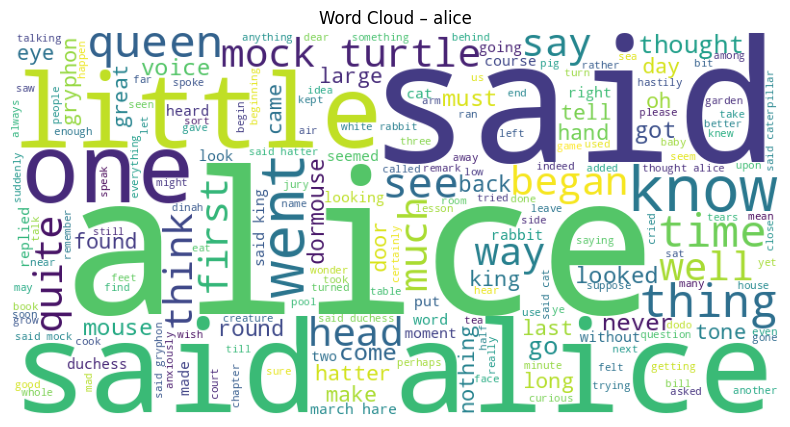

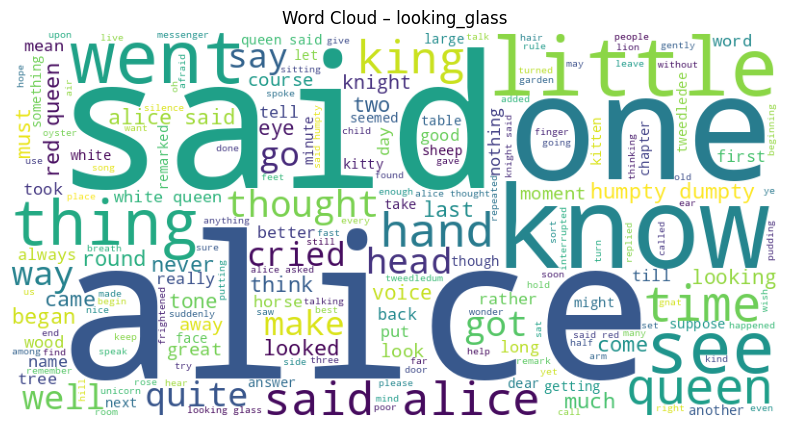

No content to generate word cloud for Word Cloud – tangled_tale


In [88]:
# II - Analysing the text
  #2.1. Using wordcloud and matplotlib, display a word cloud of each book.

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(tokens, title):
    txt = " ".join(tokens)
    if txt: # Check if the text is not empty
        wc = WordCloud(width=800, height=400, background_color="white").generate(txt)
        plt.figure(figsize=(10,5))
        plt.imshow(wc)
        plt.axis("off")
        plt.title(title)
        plt.show()
    else:
        print(f"No content to generate word cloud for {title}")


for title, toks in tokens_nostop.items():
    show_wordcloud(toks, f"Word Cloud – {title}")

In [89]:
#2.2. Use BoW method to check the five most frequent words in all the books

from collections import Counter

def top5(tokens):
    return Counter(tokens).most_common(5)

for title, toks in tokens_nostop.items():
    print(f"\n🔢 Top-5 – {title}")
    for word, freq in top5(toks):
        print(f"{word:<12} {freq}")


🔢 Top-5 – alice
said         462
alice        399
little       129
one          104
know         87

🔢 Top-5 – looking_glass
said         473
alice        468
queen        189
one          155
know         126

🔢 Top-5 – tangled_tale


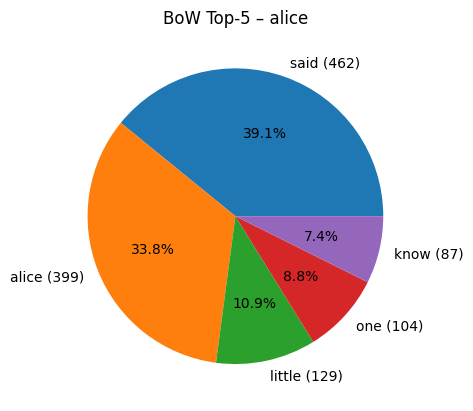

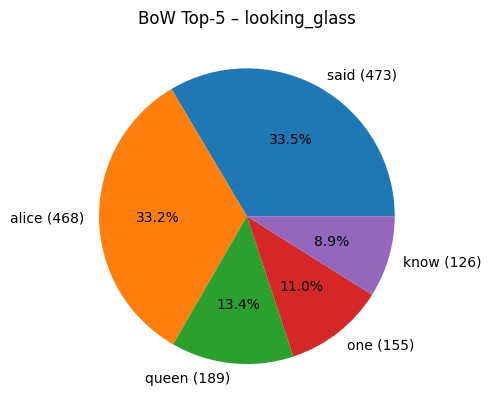

No data to create a pie chart for tangled_tale


In [95]:
#2.3. Print the BoW and identify the numbers: What is the document number? What is the index and what is how many times the word was found?

def pie_top5(counter, title):
  words, freqs = zip(*counter)
  plt.figure()
  plt.pie(freqs, labels=[f"{w} ({f})" for w, f in counter], autopct="%1.1f%%")
  plt.title(title)
  plt.show()

for title, toks in tokens_nostop.items():
    top_words = top5(toks)
    if top_words: # Add this check
        pie_top5(top_words, f"BoW Top-5 – {title}")
    else:
        print(f"No data to create a pie chart for {title}")


In [ ]:
#2.4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.





In [ ]:
#2.5. Analyse the outputs: Are those words informative? Are they insightful or expected?

# Souvent on obtient « alice, said, queen, little, time » – ces mots sont attendus, mais peu informatifs.

In [97]:
#III - Solving the frequency problem using TF-IDF
# When we create a BoW out from some text, all the words are treated equaly as importants. Like “Alice” or “say” in a fantasy book about Alice. We expected those words to be repeated all over the book, making them not so informative to us.
# The solution for this problem would be to consider the frequency relative to the corpus. In this case, if there is a word in a document that doesn’t appears much in the other documents, it is likely meaningful and should be considered more important. And the same way in the oposite: A word that is repeated a lot in all the documents will be considered less important.
# That’s the perfect situation to use TF-IDF (Term Frequency-Inverse Document Frequency)

#3.1. Create another BoW, now using TF-IDF as vectorizer. Hint: You need to pass min_df=1, max_df=2 as arguments of the TfidfVectorizer(), because we are using a small dataset.


from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,        # on passe déjà une liste de tokens
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=1, max_df=2            # requis par l’énoncé
)

docs_tokens = [" ".join(tokens_nostop[t]) for t in URLS.keys()]
tfidf = vectorizer.fit_transform(docs_tokens)
feature_names = vectorizer.get_feature_names_out()



⭐ Top-5 TF-IDF – alice
                0.5969
e               0.4175
a               0.2381
i               0.2355
t               0.2338

⭐ Top-5 TF-IDF – looking_glass
                0.6012
e               0.4297
t               0.2315
a               0.2299
i               0.2287

⭐ Top-5 TF-IDF – tangled_tale
ù               0.0000
æ               0.0000
z               0.0000
y               0.0000
x               0.0000


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128216 (\N{BLUE BOOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


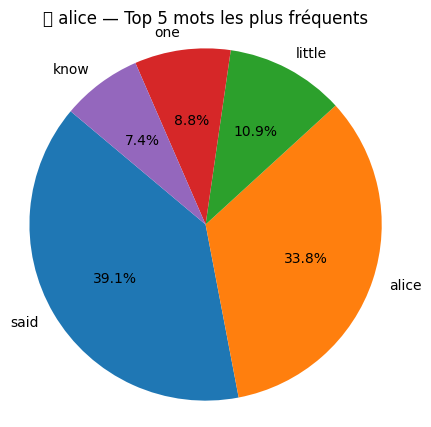

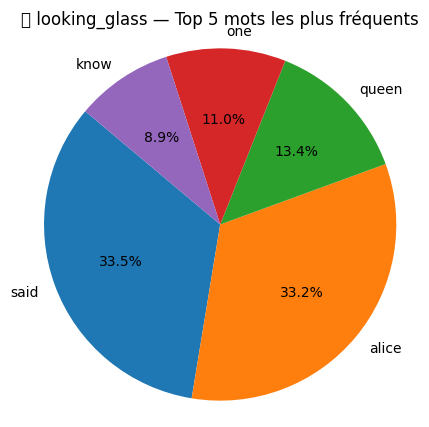

No data to create a pie chart for tangled_tale


In [100]:
#3.2. Create again the pie plots with the new 5 most relevant words from each document.

import numpy as np

def top5_tfidf(doc_id):
    row = tfidf[doc_id].toarray().flatten()
    top_idx = row.argsort()[::-1][:5]
    return [(feature_names[i], row[i]) for i in top_idx]

for i, title in enumerate(URLS.keys()):
    print(f"\n⭐ Top-5 TF-IDF – {title}")
    for w, score in top5_tfidf(i):
        print(f"{w:<15} {score:.4f}")

import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from collections import Counter
import string

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def top_5_words(text):
    words = nltk.word_tokenize(text.lower())
    words = [w for w in words if w.isalpha() and w not in stop_words]
    freq_dist = Counter(words)
    return freq_dist.most_common(5)

# Créer un pie chart pour chaque document
for title, text in corpus.items():
    top_words = top_5_words(text)
    if top_words:  # Add this check
        labels, values = zip(*top_words)

        plt.figure(figsize=(5, 5))
        plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
        plt.title(f"📘 {title} — Top 5 mots les plus fréquents")
        plt.axis('equal')  # Pour un cercle parfait
        plt.show()
    else:
        print(f"No data to create a pie chart for {title}")